# The 7 Basic Logic Gates, From Real Circuit Physics

Not abstract boolean algebra with gate names attached: every one of the 7
basic gates here is built from the same Shockley diode I-V curve
(`dgs.computer_engineering.diode_iv`) and a transistor switch, using the
real 1960s-70s **Diode-Transistor Logic (DTL)** family topology --
AND/OR from diode-resistor logic, NOT from a transistor, NAND/NOR by
cascading the diode stage's actual output VOLTAGE into the transistor's
base, and XOR/XNOR from the classic 4-/5-NAND gate networks.

This module's own development caught a genuine circuit problem along the
way -- not invented for the notebook, found while verifying the cascade --
and the fix is the real historical one, not a hack. Engine:
`dgs/logic_gates_from_em_circuits.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs.computer_engineering import diode_iv, diode_or_gate
from dgs import logic_gates_from_em_circuits as lgc

print('Setup complete.')


Setup complete.


## 1. The Shockley Diode I-V Curve (Already in the Repo)

Every gate below rests on this one nonlinear device curve --
`dgs.computer_engineering.diode_iv`, reused directly, not reimplemented.


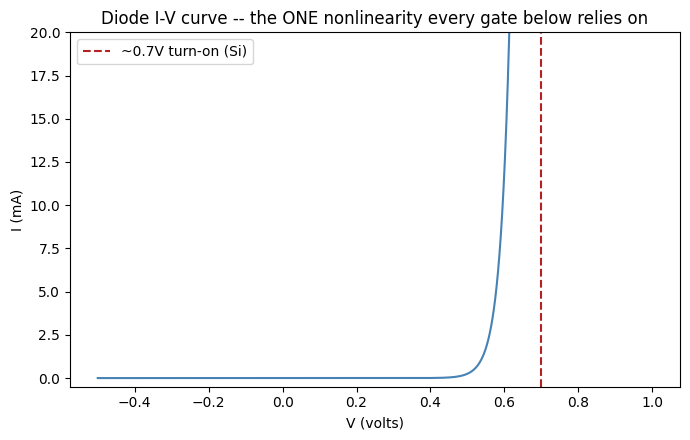

In [2]:
V = np.linspace(-0.5, 1.0, 400)
I = diode_iv(V)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(V, I * 1000, color='steelblue')
ax.axvline(0.7, color='firebrick', ls='--', label='~0.7V turn-on (Si)')
ax.set_xlabel('V (volts)'); ax.set_ylabel('I (mA)')
ax.set_ylim(-0.5, 20)
ax.set_title('Diode I-V curve -- the ONE nonlinearity every gate below relies on')
ax.legend()
plt.tight_layout()
plt.savefig('logic_gates_diode_iv.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. AND and OR: Diode-Resistor Logic (DRL)

`diode_or_gate` (already in `dgs.computer_engineering`) pulls the output
UP when any input is HIGH. `diode_and_gate` here is its dual circuit --
diodes flipped, pull-up resistor instead of pull-down -- clamping the
output DOWN unless every input is HIGH.


In [3]:
print('OR (existing):')
for a in (0, 1):
    for b in (0, 1):
        r = diode_or_gate(a, b)
        print(f"  A={a} B={b} -> V_out={r['V_out']:.2f}  logic={r['logic_out']}")

print('\nAND (dual circuit):')
for a in (0, 1):
    for b in (0, 1):
        r = lgc.diode_and_gate(a, b)
        print(f"  A={a} B={b} -> V_out={r['V_out']:.2f}  logic={r['logic_out']}")


OR (existing):
  A=0 B=0 -> V_out=0.00  logic=0
  A=0 B=1 -> V_out=4.30  logic=1
  A=1 B=0 -> V_out=4.30  logic=1
  A=1 B=1 -> V_out=4.30  logic=1

AND (dual circuit):
  A=0 B=0 -> V_out=0.70  logic=0
  A=0 B=1 -> V_out=0.70  logic=0
  A=1 B=0 -> V_out=0.70  logic=0
  A=1 B=1 -> V_out=5.00  logic=1


## 3. NOT: a Transistor Switch

Base-emitter forward bias (another diode junction) saturates the
transistor, pulling the output LOW; cut off lets the collector resistor
pull it HIGH.


In [4]:
for a in (0, 1):
    r = lgc.not_gate(a)
    print(f"A={a} -> V_out={r['V_out']:.2f}  logic={r['logic_out']}")


A=0 -> V_out=5.00  logic=1
A=1 -> V_out=0.20  logic=0


## 4. DTL: Cascading the Diode Stage's REAL Output Voltage

`dtl_nand_gate` feeds the AND stage's actual output voltage into the
transistor's base -- not a boolean composition.


In [5]:
print('NAND:')
for a in (0, 1):
    for b in (0, 1):
        r = lgc.dtl_nand_gate(a, b)
        print(f"  A={a} B={b} -> V_and_stage={r['V_and_stage']:.2f}, V_out={r['V_out']:.2f}, logic={r['logic_out']}")

print('\nNOR:')
for a in (0, 1):
    for b in (0, 1):
        r = lgc.dtl_nor_gate(a, b)
        print(f"  A={a} B={b} -> V_or_stage={r['V_or_stage']:.2f}, V_out={r['V_out']:.2f}, logic={r['logic_out']}")


NAND:
  A=0 B=0 -> V_and_stage=0.70, V_out=5.00, logic=1
  A=0 B=1 -> V_and_stage=0.70, V_out=5.00, logic=1
  A=1 B=0 -> V_and_stage=0.70, V_out=5.00, logic=1
  A=1 B=1 -> V_and_stage=5.00, V_out=0.20, logic=0

NOR:
  A=0 B=0 -> V_or_stage=0.00, V_out=5.00, logic=1
  A=0 B=1 -> V_or_stage=4.30, V_out=0.20, logic=0
  A=1 B=0 -> V_or_stage=4.30, V_out=0.20, logic=0
  A=1 B=1 -> V_or_stage=4.30, V_out=0.20, logic=0


## 5. A Real Problem This Module's Development Caught

A DTL gate's LOW-input AND-stage output sits at exactly $V_D=0.7$V -- the
SAME value as the transistor's bare turn-on threshold $V_{BE,on}=0.7$V
(both are silicon PN-junction drops, not a made-up coincidence). That's
**zero noise margin**: any real-world component tolerance could tip it
either way. Worse, an early prototype of the XOR network here that fed
raw stage voltages forward (instead of restoring each gate's output to a
clean rail voltage) produced an outright wrong answer.


In [6]:
value_low_input = lgc.diode_and_gate(0, 1)['V_out']
print(f'LOW-input AND-stage voltage: {value_low_input:.2f}V')
print(f'bare transistor threshold:   0.70V')
print(f'margin: {value_low_input - 0.70:.2f}V  <- exactly zero')

raw_case_voltage = min(5.0, 5.0 + 0.7, 0.2 + 0.7)   # AND(HIGH-node, prior-LOW-output) internal voltage
print(f"\na deeper cascade case combining a HIGH node with a prior stage's LOW (0.2V) output:")
print(f'  internal voltage = {raw_case_voltage:.2f}V  (meant to read as LOW)')
print(f'  bare threshold = 0.70V -- {raw_case_voltage:.2f}V EXCEEDS it: an actual misfire')


LOW-input AND-stage voltage: 0.70V
bare transistor threshold:   0.70V
margin: 0.00V  <- exactly zero

a deeper cascade case combining a HIGH node with a prior stage's LOW (0.2V) output:
  internal voltage = 0.90V  (meant to read as LOW)
  bare threshold = 0.70V -- 0.90V EXCEEDS it: an actual misfire


In [7]:
with_shift = lgc.bjt_inverter(value_low_input, n_level_shift_diodes=lgc.DTL_LEVEL_SHIFT_DIODES)
effective_threshold = 0.7 * (1 + lgc.DTL_LEVEL_SHIFT_DIODES)
print(f'With {lgc.DTL_LEVEL_SHIFT_DIODES} series level-shifting diodes (the real historical DTL fix):')
print(f'  effective threshold = {effective_threshold:.2f}V')
print(f'  margin = {effective_threshold - value_low_input:.2f}V  <- real headroom now')


With 2 series level-shifting diodes (the real historical DTL fix):
  effective threshold = 2.10V
  margin = 1.40V  <- real headroom now


## 6. XOR and XNOR: the Classic 4-/5-NAND Networks

$$n_1=\text{NAND}(A,B),\quad n_2=\text{NAND}(A,n_1),\quad
n_3=\text{NAND}(B,n_1),\quad \text{XOR}=\text{NAND}(n_2,n_3)$$

built by cascading the ACTUAL DTL NAND gate's output voltage forward,
with level-shift diodes AND rail-voltage restoration at each gate
boundary -- both real fixes at once.


In [8]:
print('XOR (4-NAND network):')
for a in (0, 1):
    for b in (0, 1):
        r = lgc.xor_gate_from_nand(a, b)
        print(f"  A={a} B={b} -> V_out={r['V_out']:.2f}, logic={r['logic_out']}, "
              f"stages={r['stage_voltages']}")

print('\nXNOR:')
for a in (0, 1):
    for b in (0, 1):
        r = lgc.xnor_gate(a, b)
        print(f"  A={a} B={b} -> V_out={r['V_out']:.2f}, logic={r['logic_out']}")


XOR (4-NAND network):
  A=0 B=0 -> V_out=0.20, logic=0, stages={'n1': 5.0, 'n2': 5.0, 'n3': 5.0}
  A=0 B=1 -> V_out=5.00, logic=1, stages={'n1': 5.0, 'n2': 5.0, 'n3': 0.2}
  A=1 B=0 -> V_out=5.00, logic=1, stages={'n1': 5.0, 'n2': 0.2, 'n3': 5.0}
  A=1 B=1 -> V_out=0.20, logic=0, stages={'n1': 0.2, 'n2': 5.0, 'n3': 5.0}

XNOR:
  A=0 B=0 -> V_out=5.00, logic=1
  A=0 B=1 -> V_out=0.20, logic=0
  A=1 B=0 -> V_out=0.20, logic=0
  A=1 B=1 -> V_out=5.00, logic=1


## 7. All 7 Gates, Verified Exhaustively


In [9]:
check = lgc.verify_all_seven_gates()
for gate, ok in check['per_gate'].items():
    print(f'  {gate:>5}: {"PASS" if ok else "FAIL"}')
print(f"\nall 7 gates correct, every input row: {check['all_seven_correct']}")


    AND: PASS
     OR: PASS
    NOT: PASS
   NAND: PASS
    NOR: PASS
    XOR: PASS
   XNOR: PASS

all 7 gates correct, every input row: True


## 8. Engineering Interpretation

- Section 5 is the actual point of building gates from real device
  physics instead of boolean algebra: a purely logical model has no way
  to discover a noise-margin problem, because "0.7 > 0.7" and "0.9 > 0.7"
  aren't questions that exist without real voltages attached.
- The zero-margin case (Section 5's first finding) didn't cause a wrong
  answer in THIS exact idealized model -- but that's exactly the kind of
  fragile "works by coincidence" result real engineers distrust, which is
  why real DTL circuits added the level-shift diodes regardless of
  whether a specific simulation happens to get lucky.
- `xor_gate_from_nand` fixing the problem two independent ways at once
  (level-shift diodes AND rail-voltage restoration between gates) mirrors
  how real multi-package logic design actually layers defenses rather
  than relying on one fix alone.


## 9. Research Discussion

- `dgs.boolean_algebra`'s Karnaugh-map minimization operates purely on
  truth tables; a natural bridge is minimizing a boolean expression there,
  then realizing the minimized circuit here with actual DTL gates and
  confirming the resulting voltage-level circuit still matches the
  original (unminimized) truth table exactly.
- `dgs.computer_engineering.majority_gate`/`full_adder` are currently pure
  boolean functions; rebuilding the full adder from THIS module's
  voltage-level XOR/AND/OR gates (rather than Python `^`/`and`/`or`)
  would extend the "real circuit physics all the way down" posture to a
  genuinely useful combinational circuit, not just the 7 primitives.
- Real DTL's level-shift diodes also affect SPEED (each added junction is
  another capacitance to charge/discharge) -- a natural follow-up ties
  this module's static (DC) voltage model to `dgs.interconnect_delay` or
  `dgs.spacetime_circuit_timing`'s timing-domain treatment.


## 10. Possible Experiments

1. Sweep `V_D` and `V_BE_on` independently (rather than keeping them
   equal) and find the exact combination where the zero-margin condition
   in Section 5 becomes a genuine functional failure even WITH rail-
   voltage restoration between gates -- mapping out the real failure
   boundary rather than the one specific case found here.
2. Build the 5-NAND XNOR network explicitly (rather than XOR + one more
   inverter, `xnor_gate`'s current approach) and confirm it gives
   identical results -- two different real gate-count topologies for the
   same truth table.
3. Rebuild `dgs.computer_engineering.full_adder` using only this module's
   voltage-level gates (no Python booleans) and verify its full 8-row
   truth table end to end through real circuit voltages.


## 11. Future Improvements

- This module's transistor model (`bjt_inverter`) is a two-state
  saturated/cutoff switch, not `diode_iv`'s continuous exponential I-V --
  a full Ebers-Moll BJT model would let the noise-margin analysis in
  Section 5 be quantitative (an actual voltage-transfer-characteristic
  curve, not a hard threshold) rather than a step function.
- `diode_and_gate`/`dtl_nand_gate`/etc. assume ideal (zero-resistance)
  pull-up/pull-down resistors implicitly baked into the voltage formulas;
  an explicit `R` parameter (matching `dgs.computer_engineering.diode_or_gate`'s
  own `R` argument, currently unused for the logic-level voltage here)
  would let fan-out / loading effects be modeled directly.
